In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from huggingface_hub import hf_hub_download
from datasets import load_dataset, Dataset, DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

/opt/anaconda3/envs/ml_sys/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
from dotenv import load_dotenv

load_dotenv("secrets.env")  # loads HF_TOKEN into environment
HF_TOKEN = os.getenv("HF_TOKEN")

assert HF_TOKEN and HF_TOKEN.startswith("hf_"), "HF_TOKEN missing or invalid"

In [3]:
ds = load_dataset("Tobi-Bueck/customer-support-tickets")

In [4]:
ds["train"][6]

{'subject': 'System Interruptions',
 'body': 'Dear Customer Support Team,\\n\\nI am submitting a report regarding multiple system service disruptions that are currently interfering with project operations and client interactions. These interruptions have notably reduced efficiency and caused delays in meeting important deadlines.\\n\\nInitial assessments suggest that the primary issue may be linked to widespread failures in network hardware connectivity. We have already carried out several basic troubleshooting procedures, such as rebooting devices and performing initial system checks, but the problems persist.',
 'answer': "Thank you for bringing the system disruptions to our attention. We understand the importance of maintaining stable services for project workflows and client communications, and we apologize for the inconvenience caused. To assist us in diagnosing the issue, could you please provide specific details about the affected systems or services, the approximate start time 

In [5]:
ds["train"].column_names

['subject',
 'body',
 'answer',
 'type',
 'queue',
 'priority',
 'language',
 'version',
 'tag_1',
 'tag_2',
 'tag_3',
 'tag_4',
 'tag_5',
 'tag_6',
 'tag_7',
 'tag_8']

In [6]:
type(ds)

datasets.dataset_dict.DatasetDict

In [7]:
train_ds = ds["train"]

In [8]:
train_en_ds = train_ds.filter(lambda x: x["language"] == "en")

In [9]:
df = train_en_ds.to_pandas()

In [10]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,Documentation,Feedback,NaN,NaN,NaN,NaN


In [11]:
df.shape

(28261, 16)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28261 entries, 0 to 28260
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   24622 non-null  str    
 1   body      28260 non-null  str    
 2   answer    28255 non-null  str    
 3   type      28261 non-null  str    
 4   queue     28261 non-null  str    
 5   priority  28261 non-null  str    
 6   language  28261 non-null  str    
 7   version   16338 non-null  float64
 8   tag_1     28261 non-null  str    
 9   tag_2     28245 non-null  str    
 10  tag_3     28148 non-null  str    
 11  tag_4     25677 non-null  str    
 12  tag_5     16301 non-null  str    
 13  tag_6     7908 non-null   str    
 14  tag_7     3699 non-null   str    
 15  tag_8     1608 non-null   str    
dtypes: float64(1), str(15)
memory usage: 26.6 MB


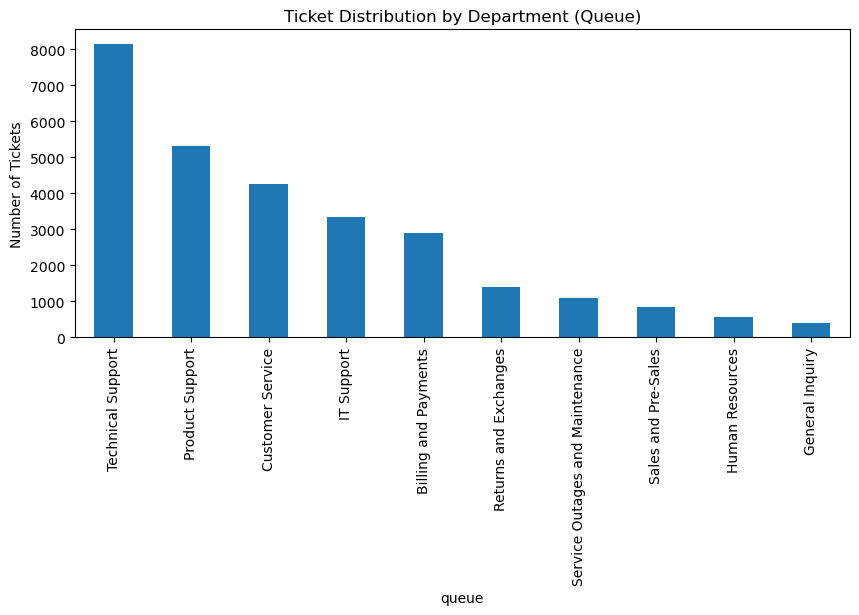

In [13]:
queue_counts = df["queue"].value_counts()

plt.figure(figsize=(10,4))
queue_counts.plot(kind="bar")
plt.title("Ticket Distribution by Department (Queue)")
plt.ylabel("Number of Tickets")
plt.show()

Missing from ds1['queue']: []


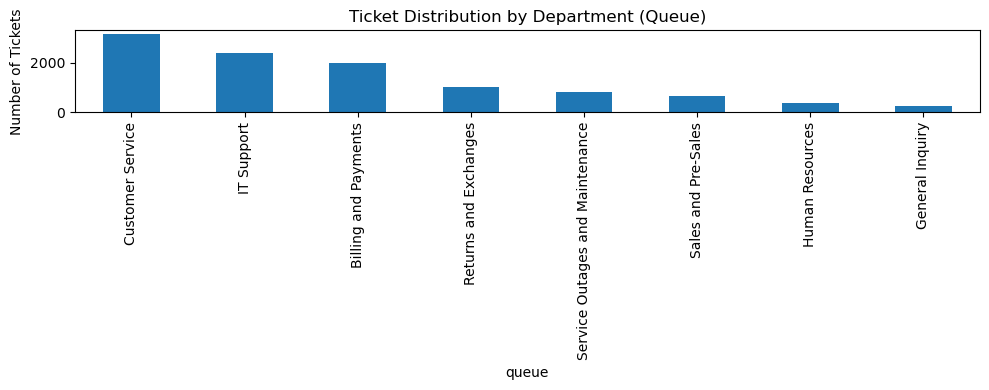

In [14]:
##### ADDING GERMAN LANGUAGE CLASSES ####
ds1 = pd.read_csv("data/df_tickets_translated_en.csv")

# Queues visible in your screenshot
QUEUES_IN_IMAGE = [
    "Customer Service",
    "IT Support",
    "Billing and Payments",
    "Returns and Exchanges",
    "Service Outages and Maintenance",
    "Sales and Pre-Sales",
    "Human Resources",
    "General Inquiry",
]

# (Optional but precise) sanity check: see if any names don't match your CSV exactly
present = set(ds1["queue"].dropna().unique())
missing = [q for q in QUEUES_IN_IMAGE if q not in present]
print("Missing from ds1['queue']:", missing)

# Filter to only those queues, then count and plot (ordered like the list above)
queue_counts = (
    ds1.loc[ds1["queue"].isin(QUEUES_IN_IMAGE), "queue"]
      .value_counts()
      .reindex(QUEUES_IN_IMAGE)
      .dropna()
)

plt.figure(figsize=(10, 4))
queue_counts.plot(kind="bar")
plt.title("Ticket Distribution by Department (Queue)")
plt.ylabel("Number of Tickets")
plt.xlabel("queue")
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

QUEUES_IN_IMAGE = [
    "Customer Service",
    "IT Support",
    "Billing and Payments",
    "Returns and Exchanges",
    "Service Outages and Maintenance",
    "Sales and Pre-Sales",
    "Human Resources",
    "General Inquiry",
]


# keep only those departments from ds1
ds1_sel = ds1[ds1["queue"].isin(QUEUES_IN_IMAGE)].copy()

# append to df (row-wise)
df = pd.concat([df, ds1_sel], ignore_index=True)

In [16]:
# ##### ADDING SYNTHETIC DATA ######
# ds_synthetic = pd.read_csv("data/final_augumented.csv")
# ds_synthetic['priority'] = ds_synthetic['priority'].str.lower()
# ds_synthetic['queue'] = ds_synthetic['queue'].str.replace('\xa0', ' ').str.strip()

# # print(df['queue'].value_counts())
# # print(ds_synthetic['queue'].value_counts())

In [17]:
##### ADDING SYNTHETIC DATA ######
ds_synthetic = pd.read_csv("data/final_augumented.csv")
ds_synthetic['priority'] = ds_synthetic['priority'].str.lower()
ds_synthetic['queue'] = ds_synthetic['queue'].str.replace('\xa0', ' ').str.strip()
ds_synthetic = ds_synthetic.reindex(columns=df.columns)

# Targeted augmentation — only minority classes, only what's needed
augmentation_targets = [
    ("General Inquiry",                 "medium", 1200),
    ("General Inquiry",                 "high",    700),
    ("General Inquiry",                 "low",     700),
    ("Human Resources",                 "medium", 1000),
    ("Human Resources",                 "high",    700),
    ("Human Resources",                 "low",     600),
    ("Sales and Pre-Sales",             "medium",  900),
    ("Sales and Pre-Sales",             "high",    600),
    ("Sales and Pre-Sales",             "low",     300),
    ("Service Outages and Maintenance", "high",    700),
    ("Service Outages and Maintenance", "medium",  500),
    ("Service Outages and Maintenance", "low",     300),
    ("Returns and Exchanges",           "medium",  500),
    ("Returns and Exchanges",           "high",    300),
    ("Returns and Exchanges",           "low",     200),
]



In [18]:
synthetic_chunks = []
for queue, priority, n in augmentation_targets:
    subset = ds_synthetic[
        (ds_synthetic['queue'] == queue) &
        (ds_synthetic['priority'] == priority)
    ]
    sampled = subset.sample(n=min(n, len(subset)), random_state=42)
    synthetic_chunks.append(sampled)
    print(f"  Added {len(sampled):>4} rows  →  [{queue}] | {priority}")

df_synthetic_targeted = pd.concat(synthetic_chunks, ignore_index=True)
df_merged = pd.concat([df, df_synthetic_targeted], ignore_index=True)
df = df_merged.copy()

print(f"\nTotal synthetic rows added : {len(df_synthetic_targeted)}")
print(f"Total dataset size         : {len(df)}")
print("\nNew class distribution:")
print(df['queue'].value_counts())

  Added 1200 rows  →  [General Inquiry] | medium
  Added  700 rows  →  [General Inquiry] | high
  Added  700 rows  →  [General Inquiry] | low
  Added 1000 rows  →  [Human Resources] | medium
  Added  700 rows  →  [Human Resources] | high
  Added  600 rows  →  [Human Resources] | low
  Added  900 rows  →  [Sales and Pre-Sales] | medium
  Added  600 rows  →  [Sales and Pre-Sales] | high
  Added  300 rows  →  [Sales and Pre-Sales] | low
  Added  700 rows  →  [Service Outages and Maintenance] | high
  Added  500 rows  →  [Service Outages and Maintenance] | medium
  Added  300 rows  →  [Service Outages and Maintenance] | low
  Added  500 rows  →  [Returns and Exchanges] | medium
  Added  300 rows  →  [Returns and Exchanges] | high
  Added  200 rows  →  [Returns and Exchanges] | low

Total synthetic rows added : 9200
Total dataset size         : 48095

New class distribution:
queue
Technical Support                  8149
Customer Service                   7420
IT Support                     

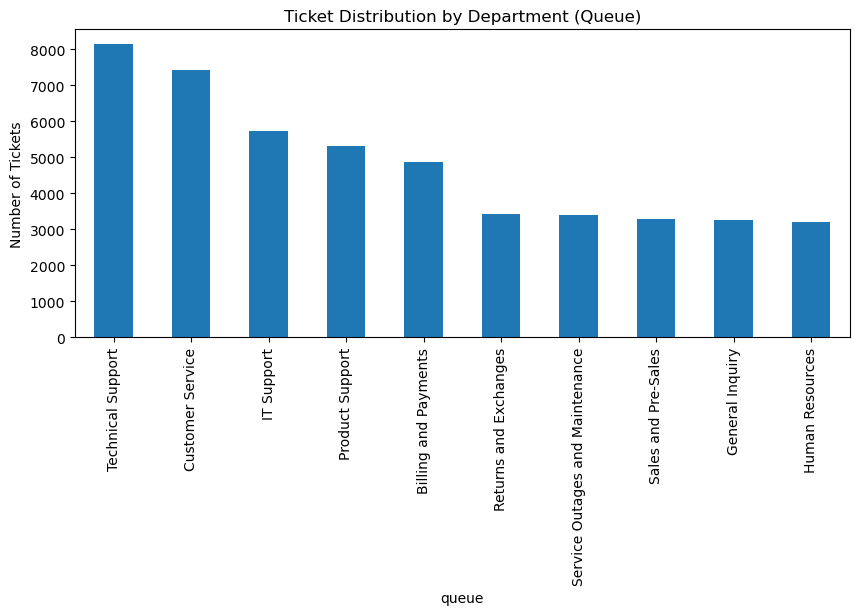

In [19]:
queue_counts = df_merged["queue"].value_counts()

plt.figure(figsize=(10,4))
queue_counts.plot(kind="bar")
plt.title("Ticket Distribution by Department (Queue)")
plt.ylabel("Number of Tickets")
plt.show()

In [20]:
# ds_synthetic=ds_synthetic.reindex(columns=df.columns)
# df_merged = pd.concat([df, ds_synthetic], ignore_index=True)

# df = df_merged.copy()
# print(df['queue'].value_counts())
# print(df['priority'].value_counts())

In [21]:
df = df.dropna(subset=['subject', 'body', 'queue', 'priority'])

In [22]:
df["text"] = (
    df["subject"].fillna("") + " " + df["body"].fillna("")
)

In [23]:
df[["subject", "body", "text"]].head(3)

,subject,body,text
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Account Disruption Dear Customer Support Team,..."
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Query About Smart Home System Integration Feat...
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry Regarding Invoice Details Dear Custome...


In [24]:
df["language"].value_counts()

language
en    43548
Name: count, dtype: int64

In [25]:
df = df[["text", "queue", "priority"]]
df.head()

,text,queue,priority
0,"Account Disruption Dear Customer Support Team,...",Technical Support,high
1,Query About Smart Home System Integration Feat...,Returns and Exchanges,medium
2,Inquiry Regarding Invoice Details Dear Custome...,Billing and Payments,low
3,Question About Marketing Agency Software Compa...,Sales and Pre-Sales,medium
4,"Feature Query Dear Customer Support,\n\nI hope...",Technical Support,high


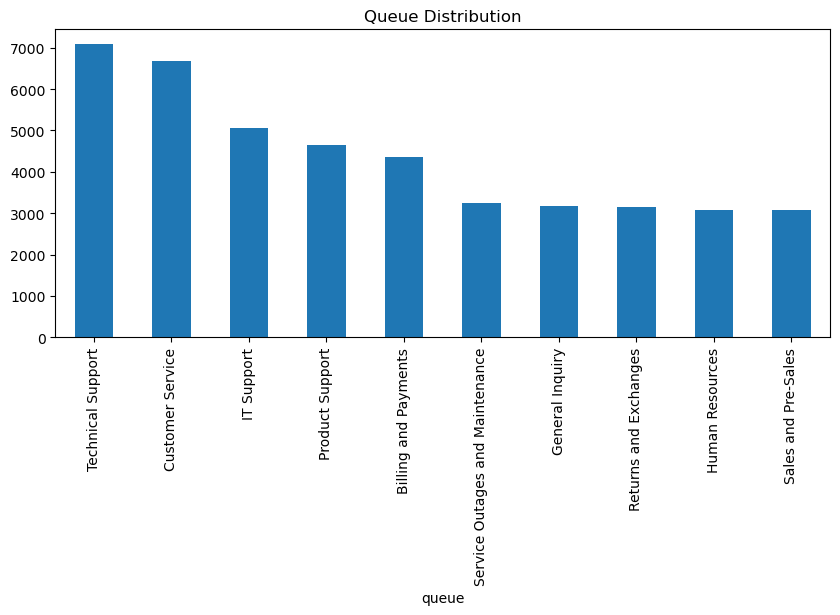

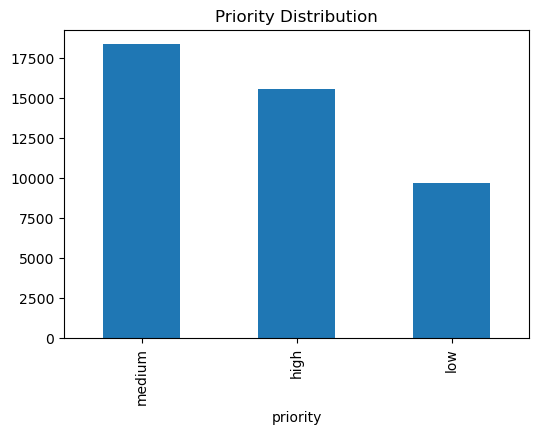

In [26]:
plt.figure(figsize=(10,4))
df["queue"].value_counts().plot(kind="bar")
plt.title("Queue Distribution")
plt.show()

plt.figure(figsize=(6,4))
df["priority"].value_counts().plot(kind="bar")
plt.title("Priority Distribution")
plt.show()

In [27]:
df["text_len"] = df["text"].str.split().str.len()

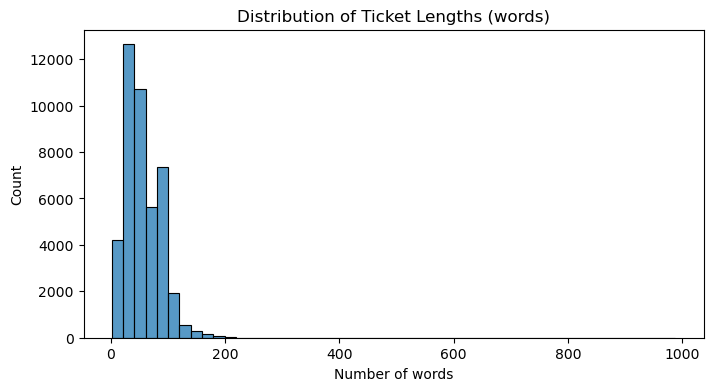

In [28]:
plt.figure(figsize=(8,4))
sns.histplot(df["text_len"], bins=50)
plt.title("Distribution of Ticket Lengths (words)")
plt.xlabel("Number of words")
plt.show()

In [29]:
df.isnull().sum().sort_values(ascending=False)

text        0
queue       0
priority    0
text_len    0
dtype: int64

In [30]:
(df["text"].str.strip() == "").sum()

0

In [31]:
df["queue"].unique()

<ArrowStringArray>
[              'Technical Support',           'Returns and Exchanges',
            'Billing and Payments',             'Sales and Pre-Sales',
 'Service Outages and Maintenance',                 'Product Support',
                      'IT Support',                'Customer Service',
                 'Human Resources',                 'General Inquiry']
Length: 10, dtype: str

In [32]:
df["priority"].unique()

<ArrowStringArray>
['high', 'medium', 'low']
Length: 3, dtype: str

In [33]:
label_summary = pd.DataFrame({
    "queue_count": df["queue"].value_counts(),
    "priority_count": df["priority"].value_counts()
})

In [34]:
label_summary

,queue_count,priority_count
Billing and Payments,4364.0,NaN
Customer Service,6670.0,NaN
General Inquiry,3175.0,NaN
Human Resources,3079.0,NaN
IT Support,5064.0,NaN
Product Support,4643.0,NaN
Returns and Exchanges,3148.0,NaN
Sales and Pre-Sales,3073.0,NaN
Service Outages and Maintenance,3242.0,NaN
Technical Support,7090.0,NaN


In [35]:
# Quick placement check — run this right before the FAISS block
print("Columns available:", df.columns.tolist())
print("text column exists:", 'text' in df.columns)
print("df size at FAISS build time:", len(df))

# Check if train/test split has already happened
import sys
print("train_df exists:", 'train_df' in dir())
print("test_df exists:", 'test_df' in dir())

Columns available: ['text', 'queue', 'priority', 'text_len']
text column exists: True
df size at FAISS build time: 43548
train_df exists: False
test_df exists: False


In [36]:
# import faiss
# import numpy as np
# import pickle
# from sentence_transformers import SentenceTransformer

# # Use a lightweight but strong embedding model
# embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# print("Encoding training corpus... (this takes a few minutes)")
# corpus_texts  = df['text'].tolist()
# corpus_queues = df['queue'].tolist()
# corpus_priorities = df['priority'].tolist()

# # Encode in batches for memory efficiency
# embeddings = embedder.encode(
#     corpus_texts,
#     batch_size=256,
#     show_progress_bar=True,
#     convert_to_numpy=True,
#     normalize_embeddings=True   # cosine similarity via inner product
# )

# print(f"Embeddings shape: {embeddings.shape}")  # (48095, 384)

# # Build FAISS index
# dimension = embeddings.shape[1]  # 384
# index = faiss.IndexFlatIP(dimension)  # Inner Product = cosine sim (since normalized)
# index.add(embeddings)

# print(f"FAISS index built with {index.ntotal} vectors")

# # Save index + metadata for later use
# faiss.write_index(index, "rag_index.faiss")

# with open("rag_metadata.pkl", "wb") as f:
#     pickle.dump({
#         "texts":      corpus_texts,
#         "queues":     corpus_queues,
#         "priorities": corpus_priorities
#     }, f)

# print("Saved: rag_index.faiss + rag_metadata.pkl")

In [37]:
import os, pickle
import faiss
from huggingface_hub import hf_hub_download

REPO_ID = "Rarry/RAG_Ticket_Trial"
HF_TOKEN = os.environ.get("HF_TOKEN")

index_path = hf_hub_download(
    repo_id=REPO_ID,
    filename="rag_index.faiss",
    token=HF_TOKEN,
)
meta_path = hf_hub_download(
    repo_id=REPO_ID,
    filename="rag_metadata.pkl",
    token=HF_TOKEN,
)

index = faiss.read_index(index_path)

with open(meta_path, "rb") as f:
    metadata = pickle.load(f)

corpus_texts = metadata["texts"]
corpus_queues = metadata["queues"]
corpus_priorities = metadata["priorities"]

print("Loaded FAISS vectors:", index.ntotal, "| metadata rows:", len(corpus_texts))

Loaded FAISS vectors: 43548 | metadata rows: 43548


In [38]:
from sentence_transformers import SentenceTransformer
import torch

EMBED_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"  # must match what was used to build rag_index.faiss
device = "mps" if torch.backends.mps.is_available() else "cpu"
embedder = SentenceTransformer(EMBED_MODEL_ID, device=device)

In [39]:
def retrieve_similar_tickets(query_text: str, k: int = 5) -> list[dict]:
    """
    Given a raw ticket text, retrieve the k most similar 
    past tickets and their correct labels from the FAISS index.
    """
    query_vec = embedder.encode(
        [query_text],
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    scores, indices = index.search(query_vec, k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({
            "text":      corpus_texts[idx][:200],
            "queue":     corpus_queues[idx],
            "priority":  corpus_priorities[idx],
            "similarity": round(float(score), 4)
        })
    return results


In [40]:
test_ticket = "My login isn't working and I can't access the system at all. It's been down since yesterday and I have a deadline today."

retrieved = retrieve_similar_tickets(test_ticket, k=5)

print(f"Query: {test_ticket}\n")
print("Top 5 Similar Tickets Retrieved:")
print("-" * 60)
for i, r in enumerate(retrieved, 1):
    print(f"{i}. [{r['queue']}] | Priority: {r['priority']} | Similarity: {r['similarity']}")
    print(f"   {r['text']}...\n")


Query: My login isn't working and I can't access the system at all. It's been down since yesterday and I have a deadline today.

Top 5 Similar Tickets Retrieved:
------------------------------------------------------------
1. [IT Support] | Priority: low | Similarity: 0.6515
   Problems Logging In on Friday Night To Customer Service, I hope this message finds you well. I am contacting you to report the login difficulties I encountered on Friday evening with my account. The i...

2. [IT Support] | Priority: low | Similarity: 0.6213
   Problems with Login on Friday Night Dear Customer Service Team, I am contacting you to report the difficulties I faced on Friday evening when attempting to access my account. These difficulties began ...

3. [General Inquiry] | Priority: medium | Similarity: 0.6062
   Disruption to Salesforce Access for Sales Team Our sales team is unable to access Salesforce due to a login error. They've tried resetting passwords, but it's still not working. Can we get as

In [41]:
def rag_predict(raw_text: str, queue_model, priority_model, 
                tokenizer, queue_id2label, priority_id2label,
                k: int = 5) -> dict:
    """
    Full RAG-augmented prediction pipeline:
    1. Retrieve k similar past tickets
    2. Build vote-weighted prior from retrieved labels
    3. Run transformer on the raw text
    4. Combine transformer confidence + RAG vote as ensemble
    """
    # Step 1: Retrieve
    retrieved = retrieve_similar_tickets(raw_text, k=k)

    # Step 2: RAG vote — weighted by similarity score
    from collections import defaultdict
    queue_votes    = defaultdict(float)
    priority_votes = defaultdict(float)

    for r in retrieved:
        queue_votes[r['queue']]       += r['similarity']
        priority_votes[r['priority']] += r['similarity']

    rag_queue_pred    = max(queue_votes,    key=queue_votes.get)
    rag_priority_pred = max(priority_votes, key=priority_votes.get)

    # Step 3: Transformer prediction
    inputs = tokenizer(
        raw_text, return_tensors="pt",
        truncation=True, max_length=512
    ).to(device)

    queue_model.eval()
    priority_model.eval()

    with torch.no_grad():
        queue_logits    = queue_model(**inputs).logits
        priority_logits = priority_model(**inputs).logits

    queue_probs    = torch.softmax(queue_logits,    dim=-1).cpu().numpy()[0]
    priority_probs = torch.softmax(priority_logits, dim=-1).cpu().numpy()[0]

    transformer_queue_id    = queue_probs.argmax()
    transformer_priority_id = priority_probs.argmax()

    transformer_queue    = queue_id2label[transformer_queue_id]
    transformer_priority = priority_id2label[transformer_priority_id]
    transformer_queue_conf = round(float(queue_probs.max()), 4)

    # Step 4: Simple ensemble — if RAG and transformer agree, boost confidence
    final_queue    = transformer_queue
    final_priority = transformer_priority
    agreement      = (rag_queue_pred == transformer_queue)

    return {
        "final_queue":           final_queue,
        "final_priority":        final_priority,
        "transformer_queue":     transformer_queue,
        "transformer_conf":      transformer_queue_conf,
        "rag_queue_vote":        rag_queue_pred,
        "rag_priority_vote":     rag_priority_pred,
        "agreement":             agreement,
        "retrieved_tickets":     retrieved,
        "queue_probs":           {queue_id2label[i]: round(float(p), 4) 
                                  for i, p in enumerate(queue_probs)}
    }


In [42]:
import os, pickle, torch
from huggingface_hub import hf_hub_download
from transformers import AutoTokenizer, AutoModelForSequenceClassification

HF_TOKEN = os.environ.get("HF_TOKEN")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

QUEUE_REPO_ID = "Rarry/queue"         # contains model+tokenizer (recommended)
PRIORITY_REPO_ID = "Rarry/Priority"   # contains model+tokenizer (or reuse same tokenizer)

# Tokenizer (if both models share same tokenizer, just load once from one repo)
tokenizer = AutoTokenizer.from_pretrained(QUEUE_REPO_ID, token=HF_TOKEN)

# Queue model
queue_model = AutoModelForSequenceClassification.from_pretrained(
    QUEUE_REPO_ID, token=HF_TOKEN
).to(device).eval()

# Priority model
priority_model = AutoModelForSequenceClassification.from_pretrained(
    PRIORITY_REPO_ID, token=HF_TOKEN
).to(device).eval()

# Label encoders (store these .pkl files in a Hub repo too)
queue_encoder_path = hf_hub_download(QUEUE_REPO_ID, "queue_encoder.pkl", token=HF_TOKEN)
priority_encoder_path = hf_hub_download(PRIORITY_REPO_ID, "priority_encoder.pkl", token=HF_TOKEN)

with open(queue_encoder_path, "rb") as f:
    queue_encoder = pickle.load(f)
with open(priority_encoder_path, "rb") as f:
    priority_encoder = pickle.load(f)

queue_id2label = {i: label for i, label in enumerate(queue_encoder.classes_)}
priority_id2label = {i: label for i, label in enumerate(priority_encoder.classes_)}

print("Queue labels    :", queue_id2label)
print("Priority labels :", priority_id2label)
print("\n✅ All models loaded successfully")


Queue labels    : {0: 'Billing and Payments', 1: 'Customer Service', 2: 'General Inquiry', 3: 'Human Resources', 4: 'IT Support', 5: 'Product Support', 6: 'Returns and Exchanges', 7: 'Sales and Pre-Sales', 8: 'Service Outages and Maintenance', 9: 'Technical Support'}
Priority labels : {0: 'high', 1: 'low', 2: 'medium'}

✅ All models loaded successfully


/opt/anaconda3/envs/ml_sys/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [43]:
# import pickle
# import torch
# from transformers import AutoTokenizer, AutoModelForSequenceClassification

# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# print(f"Using device: {device}")

# # Local paths — relative to wherever V4.ipynb is sitting
# QUEUE_MODEL_PATH      = "Rarry/queue"
# PRIORITY_MODEL_PATH   = "models/priority_v2"
# TOKENIZER_PATH        = "models/tokenizer"
# QUEUE_ENCODER_PATH    = "models/queue_encoder.pkl"
# PRIORITY_ENCODER_PATH = "models/priority_encoder.pkl"

# # Load tokenizer
# tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PATH)

# # Load queue model
# queue_model = AutoModelForSequenceClassification.from_pretrained(QUEUE_MODEL_PATH)
# queue_model.to(device)
# queue_model.eval()

# # Load priority model
# priority_model = AutoModelForSequenceClassification.from_pretrained(PRIORITY_MODEL_PATH)
# priority_model.to(device)
# priority_model.eval()

# # Load label encoders
# with open(QUEUE_ENCODER_PATH, "rb") as f:
#     queue_encoder = pickle.load(f)
# with open(PRIORITY_ENCODER_PATH, "rb") as f:
#     priority_encoder = pickle.load(f)

# # Build id → label lookup maps
# queue_id2label    = {i: label for i, label in enumerate(queue_encoder.classes_)}
# priority_id2label = {i: label for i, label in enumerate(priority_encoder.classes_)}

# print("Queue labels    :", queue_id2label)
# print("Priority labels :", priority_id2label)
# print("\n✅ All models loaded successfully")

In [44]:
def transformer_predict(text: str) -> dict:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    ).to(device)

    # DistilBERT doesn't use token_type_ids — remove it if present
    inputs.pop("token_type_ids", None)

    with torch.no_grad():
        queue_logits    = queue_model(**inputs).logits
        priority_logits = priority_model(**inputs).logits

    queue_probs    = torch.softmax(queue_logits,    dim=-1).cpu().numpy()[0]
    priority_probs = torch.softmax(priority_logits, dim=-1).cpu().numpy()[0]

    return {
        "queue":         queue_id2label[queue_probs.argmax()],
        "priority":      priority_id2label[priority_probs.argmax()],
        "queue_conf":    round(float(queue_probs.max()), 4),
        "priority_conf": round(float(priority_probs.max()), 4),
        "queue_probs":   queue_probs
    }

result = transformer_predict("My invoice is completely wrong and I was charged twice this month")
print(result)


{'queue': 'Billing and Payments', 'priority': 'medium', 'queue_conf': 0.997, 'priority_conf': 0.6145, 'queue_probs': array([9.96977806e-01, 2.51887162e-04, 7.18275551e-05, 3.79281671e-04,
       1.23457023e-04, 1.15520917e-04, 1.58618076e-03, 2.40153764e-04,
       1.04603394e-04, 1.49188389e-04], dtype=float32)}


In [45]:
# def ensemble_predict(text: str, alpha: float = 0.7) -> dict:
#     """
#     alpha = transformer weight (0.7 = 70% transformer, 30% RAG)
#     """
#     from collections import defaultdict

#     # Step 1: Transformer prediction
#     t_result = transformer_predict(text)
#     queue_probs = t_result["queue_probs"]

#     # Step 2: RAG retrieval
#     retrieved = retrieve_similar_tickets(text, k=5)

#     # Step 3: RAG vote — weighted by similarity score
#     rag_scores = defaultdict(float)
#     for r in retrieved:
#         rag_scores[r["queue"]] += r["similarity"]

#     total = sum(rag_scores.values())
#     rag_probs = {label: score / total for label, score in rag_scores.items()}

#     # Step 4: Combine transformer + RAG scores
#     combined = {}
#     for i, label in queue_id2label.items():
#         t_prob = float(queue_probs[i])
#         r_prob = rag_probs.get(label, 0.0)
#         combined[label] = alpha * t_prob + (1 - alpha) * r_prob

#     final_queue = max(combined, key=combined.get)
#     rag_queue   = max(rag_probs, key=rag_probs.get)
#     agreement   = (t_result["queue"] == rag_queue)

#     return {
#         "final_queue":       final_queue,
#         "final_priority":    t_result["priority"],
#         "transformer_queue": t_result["queue"],
#         "transformer_conf":  t_result["queue_conf"],
#         "rag_queue":         rag_queue,
#         "agreement":         agreement,
#         "all_scores":        {k: round(v, 4) for k, v in sorted(combined.items(), key=lambda x: -x[1])},
#         "retrieved_tickets": retrieved
#     }

In [46]:
def ensemble_predict(text: str, base_alpha: float = 0.7) -> dict:
    from collections import defaultdict

    t_result    = transformer_predict(text)
    queue_probs = t_result["queue_probs"]
    retrieved   = retrieve_similar_tickets(text, k=5)

    rag_scores = defaultdict(float)
    for r in retrieved:
        rag_scores[r["queue"]] += r["similarity"]
    total    = sum(rag_scores.values())
    rag_probs = {label: score / total for label, score in rag_scores.items()}

    # Dynamic alpha — trust transformer MORE when it's confident
    # If transformer is 99% sure → alpha=0.90 (almost ignore RAG)
    # If transformer is 33% sure → alpha=0.50 (equal weight to RAG)
    transformer_conf = t_result["queue_conf"]
    alpha = base_alpha + (transformer_conf - 0.5) * 0.4
    alpha = max(0.4, min(0.95, alpha))   # clamp between 0.4 and 0.95

    combined = {}
    for i, label in queue_id2label.items():
        t_prob = float(queue_probs[i])
        r_prob = rag_probs.get(label, 0.0)
        combined[label] = alpha * t_prob + (1 - alpha) * r_prob

    final_queue = max(combined, key=combined.get)
    rag_queue   = max(rag_probs, key=rag_probs.get)

    return {
        "final_queue":       final_queue,
        "final_priority":    t_result["priority"],
        "transformer_queue": t_result["queue"],
        "transformer_conf":  t_result["queue_conf"],
        "priority_conf":     t_result["priority_conf"],
        "rag_queue":         rag_queue,
        "agreement":         t_result["queue"] == rag_queue,
        "alpha_used":        round(alpha, 3),     # good for debugging/UI
        "all_scores":        {k: round(v, 4) for k, v in 
                              sorted(combined.items(), key=lambda x: -x[1])},
        "retrieved_tickets": retrieved
    }


In [47]:
test_tickets = [
    "My invoice is completely wrong and I was charged twice this month",
    "I cannot log into my account since yesterday, very urgent",
    "I want to return a product I bought last week, it was defective",
    "Our entire office internet has been down for 3 hours"
]

for ticket in test_tickets:
    result = ensemble_predict(ticket)
    agreement_str = "✅ AGREE" if result["agreement"] else "⚠️ DISAGREE"
    print(f"Ticket   : {ticket[:60]}...")
    print(f"Decision : [{result['final_queue']}] | {result['final_priority']}")
    print(f"Transformer said : {result['transformer_queue']} ({result['transformer_conf']*100:.1f}%)")
    print(f"RAG said         : {result['rag_queue']} {agreement_str}")
    print(f"Top scores       : {list(result['all_scores'].items())[:5]}")
    print("-" * 70)

Ticket   : My invoice is completely wrong and I was charged twice this ...
Decision : [Billing and Payments] | medium
Transformer said : Billing and Payments (99.7%)
RAG said         : Sales and Pre-Sales ⚠️ DISAGREE
Top scores       : [('Billing and Payments', 0.9163), ('Sales and Pre-Sales', 0.0408), ('Human Resources', 0.0205), ('General Inquiry', 0.0203), ('Returns and Exchanges', 0.0014)]
----------------------------------------------------------------------
Ticket   : I cannot log into my account since yesterday, very urgent...
Decision : [Customer Service] | medium
Transformer said : Returns and Exchanges (32.9%)
RAG said         : Customer Service ⚠️ DISAGREE
Top scores       : [('Customer Service', 0.3599), ('IT Support', 0.3298), ('Returns and Exchanges', 0.2076), ('Service Outages and Maintenance', 0.0563), ('Billing and Payments', 0.021)]
----------------------------------------------------------------------
Ticket   : I want to return a product I bought last week, it was d